In [25]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [26]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [27]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [28]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [29]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (150587401647)>


In [30]:
# User-defined variables
accMul = 2
massDen = 2.0
fluidDen = 1.0
massProportionalDamping = 0.0
stiffnessProportionalDamping = 0.001
fangle = 31.40 #31.40
ptangle = 26.50
E = 90000.0
poisson = 0.40
G = E / (2 * (1 + poisson))
B = E / (3 * (1 - 2 * poisson))
press = 0.0
deltaT = 0.010
numSteps = 2000
gamma = 0.600
period = 1
pi = math.pi
inclination = 0
unitWeightX = (massDen - fluidDen) * 9.81 * math.sin(math.radians(inclination))
unitWeightY = -(massDen - fluidDen) * 9.81 * math.cos(math.radians(inclination))

ops.wipe()
# Model
ops.model('basic', '-ndm', 2, '-ndf', 2)

# Materials
ops.nDMaterial('PressureDependMultiYield', 2, 2, massDen, G, B, fangle, .1, 80, 0.5, ptangle, 0.17, 0.4, 10, 10, 0.015, 1.0)
ops.nDMaterial('FluidSolidPorous', 1, 2, 2, 2.2e6)

# Nodes
ops.node(1, 0.0, 0.0)
ops.node(2, 1.0, 0.0)
ops.node(3, 1.0, 1.0)
ops.node(4, 0.0, 1.0)

# Element
ops.element('quad', 1, 1, 2, 3, 4, 1.0, "PlaneStrain", 1, press, 0.0, unitWeightX, unitWeightY)

ops.updateMaterialStage('-material', 2, '-stage', 0)

# Fixities
ops.fix(1, 1, 1)
ops.fix(2, 1, 1)
ops.equalDOF(3, 4, 1, 2)

# Gravity analysis (elastic)
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1e-12, 25, 0)
ops.constraints('Transformation')
ops.integrator('LoadControl', 1, 1, 1, 1)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.analysis('Static')

ops.analyze(2)

newBulk = G * 2 / 3
# --- switch the material to plastic ---
# switch material in Python

ops.parameter(1001, 'element', 1, "bulkModulus", '2')

ops.updateMaterialStage("-material", 1, "-stage", 1)
ops.updateMaterialStage("-material", 2, "-stage", 1)
ops.updateParameter(1001, newBulk) 

ops.analyze(1)


0

In [31]:
ops.printModel()

Current Domain Information
	Current Time: 3
	Committed Time: 3
NODE DATA: NumNodes: 4

numComponents: 4

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 2
	Coordinates  : 1 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 3
	Coordinates  : 1 1 
	Disps: 0 -2.54333e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 


 Node: 4
	Coordinates  : 0 1 
	Disps: 0 -2.54333e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 

ELEMENT DATA: NumEle: 1

numComponents: 1

FourNodeQuad, element id:  1
	Connected external nodes:  1 2 3 4 
	thickness:  1
	surface pressure:  0
	mass density:  0
	body forces:  0 -9.81
FluidSolidPorousMaterial
	Stress (xx yy xy)
		Gauss point 1: -3.27 -4.905 0 
		Gauss point 2: -3.27 -4.905 0 
		Gauss point 3: -3.27 -4.905 0 
		Gauss point 4: -3.27 -4.905 0 

SP_Constraints: numConstraints: 4

numComponents: 4
SP_Constraint: 0	 Node: 1 DOF: 1 ref value: 0 current value: 0 initial value: 0
SP_Constraint: 1	 Node: 1 DOF: 2 ref value: 0 current 

In [32]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [33]:
# Dynamic analysis setup
ops.setTime(0.0)
ops.wipeAnalysis()

# --- pattern for dynamic loading ---
ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
ops.pattern("UniformExcitation", 1, 1, "-accel",1)

ops.constraints('Transformation')
ops.test('NormDispIncr', 1e-6, 25, 0)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.rayleigh(massProportionalDamping, 0.0, stiffnessProportionalDamping, 0.0)
ops.integrator('Newmark', gamma, (gamma + 0.5)**2 / 4)
ops.analysis('VariableTransient')

# Recorders
ops.recorder('Node', '-file', 'ddisp.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'dacce.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'accel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'dstress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'dstrain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'dstress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'dstrain3.out', '-dT', 0.01, 'material', 3, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'dpress1.out', '-dT', 0.01, 'material', 1, 'pressure')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'dpress3.out', '-dT', 0.01, 'material', 3, 'pressure')

# Run analysis
startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 10)
endT = tt.time()

print(f"Execution time: {endT - startT} seconds.")

ops.wipe()

Execution time: 0.19576692581176758 seconds.


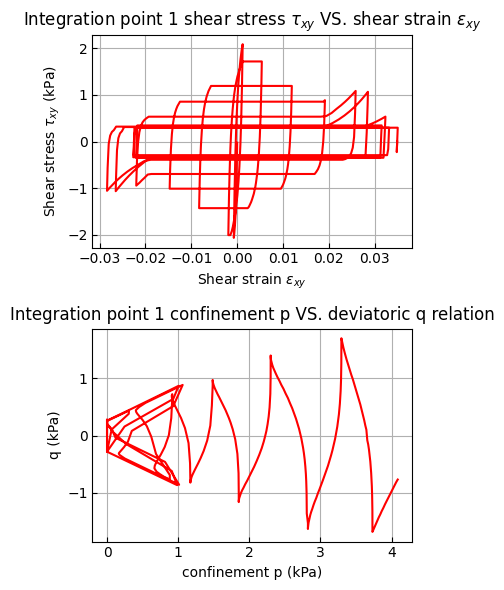

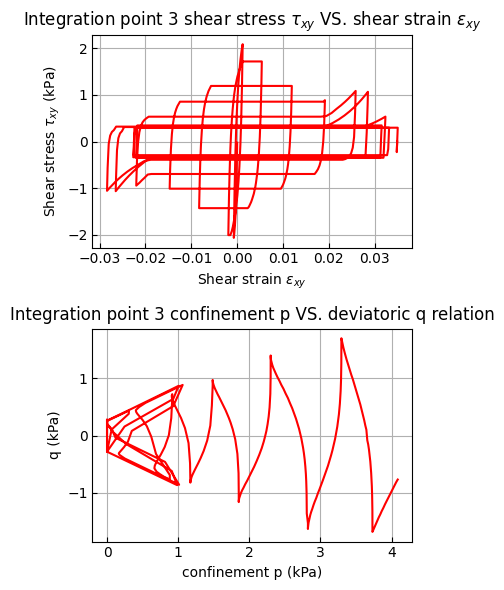

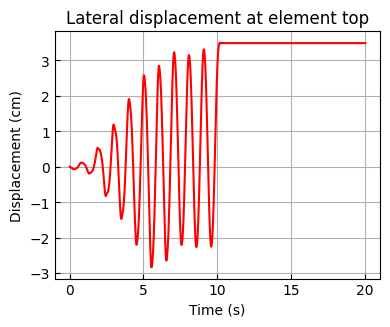

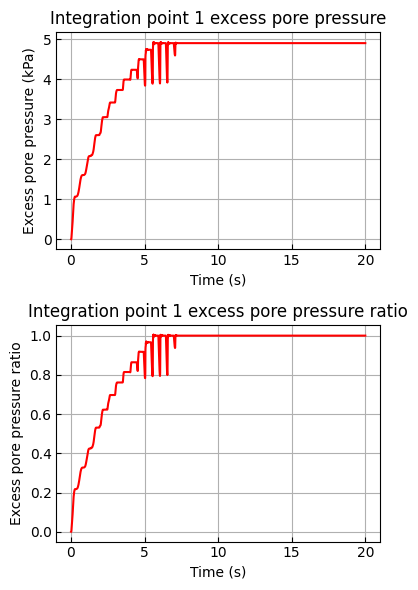

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the data from files ---
a1 = np.loadtxt('dacce.out')
d1 = np.loadtxt('ddisp.out')
s1 = np.loadtxt('dstress1.out')
e1 = np.loadtxt('dstrain1.out')
s5 = np.loadtxt('dstress3.out')
e5 = np.loadtxt('dstrain3.out')
p1 = np.loadtxt('dpress1.out')
p3 = np.loadtxt('dpress3.out')

# Define global variables
fs = [0., 0.2, 4, 6]  # [left, bottom, width, height] for paperposition

# --- 2. Helper function for p-q calculations and plotting ---
def plot_stress_strain_and_pq(stress_data, strain_data, figure_num, title_suffix, filename):
    """
    Plots the shear stress vs. shear strain and confinement vs. deviatoric stress.

    Parameters:
    - stress_data (np.ndarray): The stress data matrix.
    - strain_data (np.ndarray): The strain data matrix.
    - figure_num (int): The figure number for the plot.
    - title_suffix (str): A string for the plot titles.
    - filename (str): The base name for saving the figure.
    """
    # Calculate p (mean normal stress)
    po = (stress_data[:, 1] + stress_data[:, 2] ) / 2.0

    # Calculate q (deviatoric stress)
    term1 = (stress_data[:, 1] - stress_data[:, 2])**2
    term2 = (stress_data[:, 2] - stress_data[:, 1])**2
    
    term4 = 6.0 * stress_data[:, 3]**2
    qo = np.sqrt(term1 + term2 + term4) / 3.0
    
    # Apply the sign of s_xy (stress_data[:, 4]) to qo
    qo = np.sign(stress_data[:, 3]) * qo

    # Create the figure and subplots
    plt.figure(figure_num, figsize=(fs[2], fs[3]))
    plt.clf()
    
    # Subplot 1: Shear stress vs. shear strain
    plt.subplot(2, 1, 1)
    plt.plot(strain_data[:, 3], stress_data[:, 3], 'r')
    plt.title(f'{title_suffix} shear stress $\\tau_{{xy}}$ VS. shear strain $\\epsilon_{{xy}}$')
    plt.xlabel('Shear strain $\\epsilon_{{xy}}$')
    plt.ylabel('Shear stress $\\tau_{{xy}}$ (kPa)')
    plt.grid(True)

    # Subplot 2: Confinement vs. deviatoric stress
    plt.subplot(2, 1, 2)
    plt.plot(-po, qo, 'r')
    plt.title(f'{title_suffix} confinement p VS. deviatoric q relation')
    plt.xlabel('confinement p (kPa)')
    plt.ylabel('q (kPa)')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{filename}.jpg', dpi=300)

# --- 3. Plotting the data for different integration points ---
plot_stress_strain_and_pq(s1, e1, 1, 'Integration point 1', 'SS_PQ1')
plot_stress_strain_and_pq(s5, e5, 4, 'Integration point 3', 'SS_PQ5')

# --- 4. Plotting displacement data ---
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
# Note: The MATLAB code has a subplot(2,1,1) but only one plot.
# We'll replicate that structure.
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 5] * 100, 'r')
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (cm)')
plt.grid(True)
plt.tight_layout()
plt.savefig('D.jpg', dpi=300)

# --- 5. Plotting pore pressure data ---
plt.figure(5, figsize=(fs[2], fs[3]))
plt.clf()

# Subplot 1: Excess pore pressure
plt.subplot(2, 1, 1)
plt.plot(p1[:, 0], -p1[:, 1], 'r')
plt.title('Integration point 1 excess pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')
plt.grid(True)

# Subplot 2: Excess pore pressure ratio
plt.subplot(2, 1, 2)
plt.plot(p1[:, 0], p1[:, 2], 'r')
plt.title('Integration point 1 excess pore pressure ratio')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure ratio')
plt.grid(True)

plt.tight_layout()
plt.savefig('EPWP.jpg', dpi=300)

plt.show()

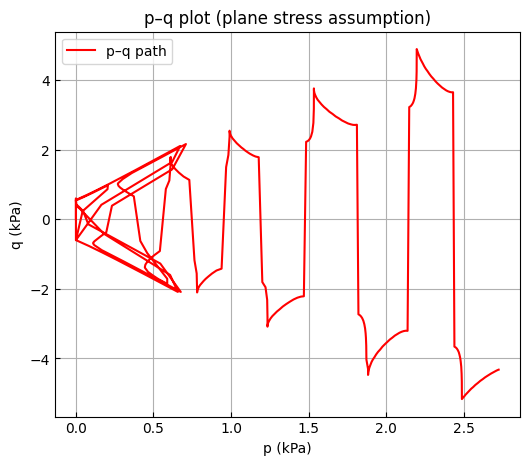

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Load file
data = np.loadtxt("dstress1.out")

time = data[:,0]
sigma_xx = data[:,1]   # σ11
sigma_yy = data[:,2]   # σ22
tau_xy   = data[:,3]   # τ12

# Plane stress assumption: σzz = 0
sigma_zz = np.zeros_like(sigma_xx)

# Mean stress p
p = (sigma_xx + sigma_yy + sigma_zz) / 3.0

# Deviatoric components
s_xx = sigma_xx - p
s_yy = sigma_yy - p
s_zz = sigma_zz - p
s_xy = tau_xy
s_yz = np.zeros_like(s_xx)
s_zx = np.zeros_like(s_xx)

# J2 invariant
J2 = 0.5 * (s_xx**2 + s_yy**2 + s_zz**2 +2*(s_xy**2 + s_yz**2 + s_zx**2))

# Deviatoric stress q
q = np.sqrt(3.0 * J2)

# Optional: sign for shear direction
q_signed = np.sign(tau_xy) * q

# --- Plot ---
plt.figure(figsize=(6,5))
plt.plot(-p, q_signed, 'r-', label='p–q path')
plt.xlabel('p (kPa)')
plt.ylabel('q (kPa)')
plt.title('p–q plot (plane stress assumption)')
plt.legend()
plt.grid(True)
plt.show()


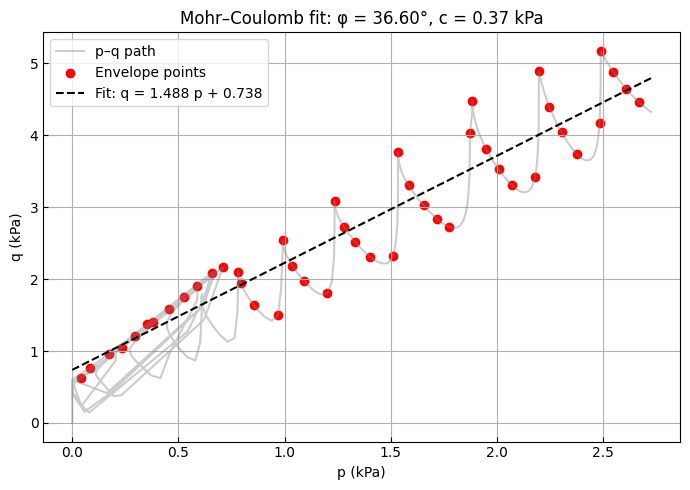

Fitted Mohr–Coulomb parameters:
  Friction angle φ  = 36.60°
  Cohesion c        = 0.37 kPa


In [36]:
import numpy as np
import matplotlib.pyplot as plt

def compute_p_q_from_opensees(sigma_xx, sigma_yy, tau_xy):
    """
    Compute p and q from σ11, σ22, τ12 using plane stress assumption (σzz = 0)
    """
    sigma_zz = np.zeros_like(sigma_xx)  # Plane stress assumption
    p = (sigma_xx + sigma_yy + sigma_zz) / 3.0

    # Deviatoric stress components
    s_xx = sigma_xx - p
    s_yy = sigma_yy - p
    s_zz = sigma_zz - p
    s_xy = tau_xy

    J2 = 0.5 * (s_xx**2 + s_yy**2 + s_zz**2 + 2 * s_xy**2)
    q = np.sqrt(3 * J2)

    return p, q

def fit_mohr_coulomb(p, q, nbins= 45, show_plot=True):
    """
    Fit a Mohr–Coulomb envelope (q = M*p + B) from the upper envelope of p–q data.
    Returns: slope M, intercept B, friction angle φ (deg), cohesion c
    """
    # Bin p into nbins and get max q per bin (envelope points)
    edges = np.linspace(np.min(p), np.max(p), nbins+1)
    p_env, q_env = [], []
    for i in range(nbins):
        mask = (p >= edges[i]) & (p < edges[i+1])
        if np.any(mask):
            idx = np.argmax(q[mask])
            p_env.append(p[mask][idx])
            q_env.append(q[mask][idx])
    p_env = np.array(p_env)
    q_env = np.array(q_env)

    # Fit q = m*p + b
    m, b = np.polyfit(p_env, q_env, 1)

    # Compute phi and cohesion
    s = 3*m / (6 + m)  # sin(phi)
    s = np.clip(s, -0.9999, 0.9999)
    phi_rad = np.arcsin(s)
    phi_deg = np.degrees(phi_rad)
    cos_phi = np.sqrt(1 - s**2)
    c = b * (3 - s) / (6 * cos_phi)

    # Plot
    if show_plot:
        p_line = np.linspace(np.min(p), np.max(p), 100)
        q_line = m * p_line + b

        plt.figure(figsize=(7,5))
        plt.plot(p, q, 'gray', alpha=0.4, label='p–q path')
        plt.scatter(p_env, q_env, c='r', label='Envelope points')
        plt.plot(p_line, q_line, 'k--', label=f'Fit: q = {m:.3f} p + {b:.3f}')
        plt.xlabel('p (kPa)')
        plt.ylabel('q (kPa)')
        plt.title(f'Mohr–Coulomb fit: φ = {phi_deg:.2f}°, c = {c:.2f} kPa')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return m, b, phi_deg, c

# === Main ===
# Replace with your actual file path
filename = "dstress1.out"
data = np.loadtxt(filename)

time = data[:,0]
sigma_11 = data[:,1]  # σ11
sigma_22 = data[:,2]  # σ22
tau_12   = data[:,3]  # τ12

# Compute p–q
p, q = compute_p_q_from_opensees(sigma_11, sigma_22, tau_12)

# Flip sign of p to use compression-positive convention
p_plot = -p

# Fit and extract parameters
m, b, phi_deg, c = fit_mohr_coulomb(p_plot, q)

# Print results
print("Fitted Mohr–Coulomb parameters:")
print(f"  Friction angle φ  = {phi_deg:.2f}°")
print(f"  Cohesion c        = {c:.2f} kPa")
